LSTM MODEL V6 September 3rd, 2024

Model Performance train on one session, test on all the other. 

- Cross-Session Testing in the same animal to isolate sessions not representative of movement. 

In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import torch 
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import random

In [2]:
# Check torch version
print('Torch Version:',torch.__version__)
print()

# Check torch cuda compatibility 
print('Torch Cuda Compatibility:',torch.version.cuda)
print()

# Check if GPU is available
print('Is the GPU available?', torch.cuda.is_available())
print('CUDA version:', torch.version.cuda)

Torch Version: 2.0.1+cu117

Torch Cuda Compatibility: 11.7

Is the GPU available? True
CUDA version: 11.7


In [3]:
# CHECK NUMBER OF GPUs

print(torch.cuda.device_count())

1


In [4]:
# Device Object - CPU and GPU 
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

Device cuda


In [5]:
# Load Data - YH16

# 03/06
X_240306_L = pd.read_csv('Kinematics Data/YH16_240306_Kinematics_All.csv')
Y_240306_L = pd.read_csv('Neural Data/YH16_240306_L_IRN_Single_Trial.csv')

X_240306_R = pd.read_csv('Kinematics Data/YH16_240306_Kinematics_All.csv')
Y_240306_R = pd.read_csv('Neural Data/YH16_240306_R_IRN_Single_Trial.csv')

# 03/07
X_240307_L = pd.read_csv('Kinematics Data/YH16_240307_Kinematics_All.csv')
Y_240307_L = pd.read_csv('Neural Data/YH16_240307_L_IRN_Single_Trial.csv')

X_240307_R = pd.read_csv('Kinematics Data/YH16_240307_Kinematics_All.csv')
Y_240307_R = pd.read_csv('Neural Data/YH16_240307_R_IRN_Single_Trial.csv')

# 03/08
X_240308_L = pd.read_csv('Kinematics Data/YH16_240308_Kinematics_All.csv')
Y_240308_L = pd.read_csv('Neural Data/YH16_240308_L_IRN_Single_Trial.csv')

X_240308_R = pd.read_csv('Kinematics Data/YH16_240308_Kinematics_All.csv')
Y_240308_R = pd.read_csv('Neural Data/YH16_240308_R_IRN_Single_Trial.csv')

In [6]:
# Load Data - YH28

# 06/28
X_240628_L = pd.read_csv('Kinematics Data/YH28_240628_Kinematics_All.csv')
Y_240628_L = pd.read_csv('Neural Data/YH28_240628_L_IRN_Single_Trial.csv')

X_240628_R = pd.read_csv('Kinematics Data/YH28_240628_Kinematics_All.csv')
Y_240628_R = pd.read_csv('Neural Data/YH28_240628_R_IRN_Single_Trial.csv')

# 06/30
X_240630_L = pd.read_csv('Kinematics Data/YH28_240630_Kinematics_All.csv')
Y_240630_L = pd.read_csv('Neural Data/YH28_240630_L_IRN_Single_Trial.csv')

X_240630_R = pd.read_csv('Kinematics Data/YH28_240630_Kinematics_All.csv')
Y_240630_R = pd.read_csv('Neural Data/YH28_240630_R_IRN_Single_Trial.csv')

# 07/01
X_240701_L = pd.read_csv('Kinematics Data/YH28_240701_Kinematics_All.csv')
Y_240701_L = pd.read_csv('Neural Data/YH28_240701_L_IRN_Single_Trial.csv')

X_240701_R = pd.read_csv('Kinematics Data/YH28_240701_Kinematics_All.csv')
Y_240701_R = pd.read_csv('Neural Data/YH28_240701_R_IRN_Single_Trial.csv')

# 07/02
X_240702_L = pd.read_csv('Kinematics Data/YH28_240702_Kinematics_All.csv')
Y_240702_L = pd.read_csv('Neural Data/YH28_240702_L_IRN_Single_Trial.csv')

X_240702_R = pd.read_csv('Kinematics Data/YH28_240702_Kinematics_All.csv')
Y_240702_R = pd.read_csv('Neural Data/YH28_240702_R_IRN_Single_Trial.csv')

In [7]:
# Load Data - YH31

# 08/03
X_240803_L = pd.read_csv('Kinematics Data/YH31_240803_Kinematics_All.csv')
Y_240803_L = pd.read_csv('Neural Data/YH31_240803_L_IRN_Single_Trial.csv')

X_240803_R = pd.read_csv('Kinematics Data/YH31_240803_Kinematics_All.csv')
Y_240803_R = pd.read_csv('Neural Data/YH31_240803_R_IRN_Single_Trial.csv')

# 08/04
X_240804_L = pd.read_csv('Kinematics Data/YH31_240804_Kinematics_All.csv')
Y_240804_L = pd.read_csv('Neural Data/YH31_240804_L_IRN_Single_Trial.csv')

X_240804_R = pd.read_csv('Kinematics Data/YH31_240804_Kinematics_All.csv')
Y_240804_R = pd.read_csv('Neural Data/YH31_240804_R_IRN_Single_Trial.csv')

# 08/05
X_240805_L = pd.read_csv('Kinematics Data/YH31_240805_Kinematics_All.csv')
Y_240805_L = pd.read_csv('Neural Data/YH31_240805_L_IRN_Single_Trial.csv')

X_240805_R = pd.read_csv('Kinematics Data/YH31_240805_Kinematics_All.csv')
Y_240805_R = pd.read_csv('Neural Data/YH31_240805_R_IRN_Single_Trial.csv')

# 08/06
X_240806_L = pd.read_csv('Kinematics Data/YH31_240806_Kinematics_All.csv')
Y_240806_L = pd.read_csv('Neural Data/YH31_240806_L_IRN_Single_Trial.csv')

X_240806_R = pd.read_csv('Kinematics Data/YH31_240806_Kinematics_All.csv')
Y_240806_R = pd.read_csv('Neural Data/YH31_240806_R_IRN_Single_Trial.csv')

# 08/07
X_240807_L = pd.read_csv('Kinematics Data/YH31_240807_Kinematics_All.csv')
Y_240807_L = pd.read_csv('Neural Data/YH31_240807_L_IRN_Single_Trial.csv')

X_240807_R = pd.read_csv('Kinematics Data/YH31_240807_Kinematics_All.csv')
Y_240807_R = pd.read_csv('Neural Data/YH31_240807_R_IRN_Single_Trial.csv')


In [8]:
# Data Preprocessing 
# PCA on Neural Data
# Z-scoring Kinematic Data
from scipy.stats import zscore 

def preprocess_data(X, Y, trial_len, PCs, session_id):

    
    # Drop Trial Type Column 
    if 'Trial Type' in X.columns: 
        X = X.drop(columns = ['Trial Type'])
    if 'Trial Type' in Y.columns: 
        Y = Y.drop(columns = ['Trial Type'])
    
    X = X.to_numpy()
    Y = Y.to_numpy()
    
    # Z - scoring Kinematic Features (X)
    # X = X[:,:-1]
    X = zscore(X, axis = 0)
    
    # Perform SVD on the activity data to get principal components
    A = (Y - np.mean(Y, axis=0)).T
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    V = Vt.T
    
    # Eigenvalues
    var_exp_pc = [(S[i]**2) / np.sum(S**2) for i in range(PCs)]
    
    # Perform Dimensionality Reduction
    S = np.diag(S)
    Y_pc = V[:, :PCs] @ S[:PCs, :PCs]
    
    # Calculate Variance in Each PC
    var_pc = [np.var(Y_pc[:,i]) for i in range(PCs)]
    

    # Session_ID array
    ID_array = session_id * np.ones((X.shape[0], 1))

    X_ID = np.concatenate((X, ID_array), axis = 1)
    Y_ID = np.concatenate((Y_pc, ID_array), axis = 1)

    X_reshaped = X_ID.reshape((X.shape[0] // trial_len, trial_len, X.shape[1] + 1))
    Y_reshaped = Y_ID.reshape((Y.shape[0] // trial_len, trial_len, PCs + 1)) 


    return X_reshaped, Y_reshaped, var_exp_pc, var_pc

In [9]:
# Generate New X and Y 
trial_len = 350
PCs = 8

# --------------------------------------------------------- YH16 -----------------------------------------------------------
X_240306_L_reshaped, Y_240306_L_reshaped, exp_var_240306_L, var_pre_240306_L = preprocess_data(X_240306_L, Y_240306_L, trial_len, PCs, 1)
X_240306_R_reshaped, Y_240306_R_reshaped, exp_var_240306_R, var_pre_240306_R = preprocess_data(X_240306_R, Y_240306_R, trial_len, PCs, 2)

X_240307_L_reshaped, Y_240307_L_reshaped, exp_var_240307_L, var_pre_240307_L = preprocess_data(X_240307_L, Y_240307_L, trial_len, PCs, 3)
X_240307_R_reshaped, Y_240307_R_reshaped, exp_var_240307_R, var_pre_240307_R = preprocess_data(X_240307_R, Y_240307_R, trial_len, PCs, 4)

X_240308_L_reshaped, Y_240308_L_reshaped, exp_var_240308_L, var_pre_240308_L = preprocess_data(X_240308_L, Y_240308_L, trial_len, PCs, 5)
X_240308_R_reshaped, Y_240308_R_reshaped, exp_var_240308_R, var_pre_240308_R = preprocess_data(X_240308_R, Y_240308_R, trial_len, PCs, 6)

# --------------------------------------------------------- YH28 -----------------------------------------------------------
X_240628_L_reshaped, Y_240628_L_reshaped, exp_var_240628_L, var_pre_240628_L = preprocess_data(X_240628_L, Y_240628_L, trial_len, PCs, 7)
X_240628_R_reshaped, Y_240628_R_reshaped, exp_var_240628_R, var_pre_240628_R = preprocess_data(X_240628_R, Y_240628_R, trial_len, PCs, 8)

X_240630_L_reshaped, Y_240630_L_reshaped, exp_var_240630_L, var_pre_240630_L = preprocess_data(X_240630_L, Y_240630_L, trial_len, PCs, 9)
X_240630_R_reshaped, Y_240630_R_reshaped, exp_var_240630_R, var_pre_240630_R = preprocess_data(X_240630_R, Y_240630_R, trial_len, PCs, 10)

X_240701_L_reshaped, Y_240701_L_reshaped, exp_var_240701_L, var_pre_240701_L = preprocess_data(X_240701_L, Y_240701_L, trial_len, PCs, 11)
X_240701_R_reshaped, Y_240701_R_reshaped, exp_var_240701_R, var_pre_240701_R = preprocess_data(X_240701_R, Y_240701_R, trial_len, PCs, 12)

X_240702_L_reshaped, Y_240702_L_reshaped, exp_var_240702_L, var_pre_240702_L = preprocess_data(X_240702_L, Y_240702_L, trial_len, PCs, 13)
X_240702_R_reshaped, Y_240702_R_reshaped, exp_var_240702_R, var_pre_240702_R = preprocess_data(X_240702_R, Y_240702_R, trial_len, PCs, 14)

# --------------------------------------------------------- YH31 -----------------------------------------------------------
X_240803_L_reshaped, Y_240803_L_reshaped, exp_var_240803_L, var_pre_240803_L = preprocess_data(X_240803_L, Y_240803_L, trial_len, PCs, 15)
X_240803_R_reshaped, Y_240803_R_reshaped, exp_var_240803_R, var_pre_240803_R = preprocess_data(X_240803_R, Y_240803_R, trial_len, PCs, 16)

X_240804_L_reshaped, Y_240804_L_reshaped, exp_var_240804_L, var_pre_240804_L = preprocess_data(X_240804_L, Y_240804_L, trial_len, PCs, 17)
X_240804_R_reshaped, Y_240804_R_reshaped, exp_var_240804_R, var_pre_240804_R = preprocess_data(X_240804_R, Y_240804_R, trial_len, PCs, 18)

X_240805_L_reshaped, Y_240805_L_reshaped, exp_var_240805_L, var_pre_240805_L = preprocess_data(X_240805_L, Y_240805_L, trial_len, PCs, 19)
X_240805_R_reshaped, Y_240805_R_reshaped, exp_var_240805_R, var_pre_240805_R = preprocess_data(X_240805_R, Y_240805_R, trial_len, PCs, 20)

X_240806_L_reshaped, Y_240806_L_reshaped, exp_var_240806_L, var_pre_240806_L = preprocess_data(X_240806_L, Y_240806_L, trial_len, PCs, 21)
X_240806_R_reshaped, Y_240806_R_reshaped, exp_var_240806_R, var_pre_240806_R = preprocess_data(X_240806_R, Y_240806_R, trial_len, PCs, 22)

X_240807_L_reshaped, Y_240807_L_reshaped, exp_var_240807_L, var_pre_240807_L = preprocess_data(X_240807_L, Y_240807_L, trial_len, PCs, 23)
X_240807_R_reshaped, Y_240807_R_reshaped, exp_var_240807_R, var_pre_240807_R = preprocess_data(X_240807_R, Y_240807_R, trial_len, PCs, 24)

In [10]:
print(X_240807_R_reshaped.shape)
print(Y_240807_R_reshaped.shape)


(282, 350, 56)
(282, 350, 9)


In [11]:
# Test and Train split for Different Sessions
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset, random_split

# Function for creating Data Loaders
def create_dataloader(X, Y, batch_size=10):
    data = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(Y).float())
    dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
    return dataloader

In [12]:
# Create Loaders for YH16 
loader_240306_L = create_dataloader(X_240306_L_reshaped, Y_240306_L_reshaped)
loader_240306_R = create_dataloader(X_240306_R_reshaped, Y_240306_R_reshaped)
loader_240307_L = create_dataloader(X_240307_L_reshaped, Y_240307_L_reshaped)
loader_240307_R = create_dataloader(X_240307_R_reshaped, Y_240307_R_reshaped)
loader_240308_L = create_dataloader(X_240308_L_reshaped, Y_240308_L_reshaped)
loader_240308_R = create_dataloader(X_240308_R_reshaped, Y_240308_R_reshaped)

 # Create Loaders for YH28
loader_240628_L = create_dataloader(X_240628_L_reshaped, Y_240628_L_reshaped)
loader_240628_R = create_dataloader(X_240628_R_reshaped, Y_240628_R_reshaped)
loader_240630_L = create_dataloader(X_240630_L_reshaped, Y_240630_L_reshaped)
loader_240630_R = create_dataloader(X_240630_R_reshaped, Y_240630_R_reshaped)
loader_240701_L = create_dataloader(X_240701_L_reshaped, Y_240701_L_reshaped)
loader_240701_R = create_dataloader(X_240701_R_reshaped, Y_240701_R_reshaped)
loader_240702_L = create_dataloader(X_240702_L_reshaped, Y_240702_L_reshaped)
loader_240702_R = create_dataloader(X_240702_R_reshaped, Y_240702_R_reshaped)

# Create Loaders for YH31
loader_240803_L = create_dataloader(X_240803_L_reshaped, Y_240803_L_reshaped)
loader_240803_R = create_dataloader(X_240803_R_reshaped, Y_240803_R_reshaped)
loader_240804_L = create_dataloader(X_240804_L_reshaped, Y_240804_L_reshaped)
loader_240804_R = create_dataloader(X_240804_R_reshaped, Y_240804_R_reshaped)
loader_240805_L = create_dataloader(X_240805_L_reshaped, Y_240805_L_reshaped)
loader_240805_R = create_dataloader(X_240805_R_reshaped, Y_240805_R_reshaped)
loader_240806_L = create_dataloader(X_240806_L_reshaped, Y_240806_L_reshaped)
loader_240806_R = create_dataloader(X_240806_R_reshaped, Y_240806_R_reshaped)
loader_240807_L = create_dataloader(X_240807_L_reshaped, Y_240807_L_reshaped)
loader_240807_R = create_dataloader(X_240807_R_reshaped, Y_240807_R_reshaped)

In [13]:
# Extract Batches Function
def extract_batches(loader):
    batches = []
    for batch in loader: 
        batches.append(batch)
    return batches

============================================================== MODEL =======================================================

In [267]:
import torch.nn as nn 

class LSTM_model(nn.Module):
    def __init__(self, input_dim, hidden_dim1, output_dim, num_layers):
        super(LSTM_model, self).__init__()
        self.hidden_dim1 = hidden_dim1
        self.num_layers = num_layers
        # self.test_session_id = test_session_id  

        self.lstm = nn.LSTM(input_dim, hidden_dim1, num_layers, batch_first=True, bias=True, dropout=0.3)
        self.relu = nn.ReLU()

        # Linear layers for each session
        self.fc_layers = nn.ModuleDict({
            # '1': nn.Linear(hidden_dim1, output_dim),
            # '2': nn.Linear(hidden_dim1, output_dim),
            # '3': nn.Linear(hidden_dim1, output_dim),
            # '4': nn.Linear(hidden_dim1, output_dim),
            # '5': nn.Linear(hidden_dim1, output_dim), 
            # '6': nn.Linear(hidden_dim1, output_dim), 
            # '7': nn.Linear(hidden_dim1, output_dim),
            # '8': nn.Linear(hidden_dim1, output_dim),
            # '9': nn.Linear(hidden_dim1, output_dim),
            # '10': nn.Linear(hidden_dim1, output_dim),
            # '11': nn.Linear(hidden_dim1, output_dim),
            # '12': nn.Linear(hidden_dim1, output_dim),
            # '13': nn.Linear(hidden_dim1, output_dim),
            # '14': nn.Linear(hidden_dim1, output_dim),
            # '15': nn.Linear(hidden_dim1, output_dim),
            # '16': nn.Linear(hidden_dim1, output_dim),
            # '17': nn.Linear(hidden_dim1, output_dim),
            # '18': nn.Linear(hidden_dim1, output_dim),
            # '19': nn.Linear(hidden_dim1, output_dim),
            # '20': nn.Linear(hidden_dim1, output_dim),
            # '21': nn.Linear(hidden_dim1, output_dim),
            # '22': nn.Linear(hidden_dim1, output_dim),
            # '23': nn.Linear(hidden_dim1, output_dim),
            '24': nn.Linear(hidden_dim1, output_dim),
            
            
        })

    def forward(self, x):
        session_id = int(x[1, :, -1][0].item())
        x = x[:, :, :-1]

        # LSTM forward pass
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim1).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim1).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.relu(out)

        # # Check if the session ID matches the test session ID
        # if session_id == self.test_session_id:
        #     print(f"Unexpected Session ID: {session_id} (Test Session)")
        #     return out  # Output without applying a linear layer for the test session
        # else:
        # Apply the corresponding linear layer
        if str(session_id) in self.fc_layers:
            out = self.fc_layers[str(session_id)](out)
        else:
            print(f"Unexpected Session ID: {session_id}")
            return out

        return out

In [268]:
# Set LSTM Model Parameters

# Parameters
input_dim = 55  # Input dimension to LSTM
hidden_dim1 = 128  # Hidden dimension of LSTM
output_dim = PCs  # Number of principal components (PCs)
num_layers = 3  # LSTM Layers

In [269]:
# Model Optimizer and Loss Function 

import torch.optim as optim

Loss_fcn = nn.MSELoss()

# R-squared Function 
from sklearn.metrics import r2_score

In [270]:
# Setting up Train and Test Dataset
YH16_loaders = [loader_240306_L, loader_240306_R, loader_240307_L, loader_240307_R, loader_240308_L, loader_240308_R]
YH28_loaders = [loader_240628_L, loader_240628_R, loader_240630_L, loader_240630_R, loader_240701_L, loader_240701_R, loader_240702_L, loader_240702_R]
YH31_loaders = [loader_240803_L, loader_240803_R, loader_240804_L, loader_240804_R, loader_240805_L, loader_240805_R, loader_240806_L, loader_240806_R, loader_240807_L, loader_240807_R]

train_loader = loader_240807_R
test_loaders = [loader_240803_L, loader_240803_R, loader_240804_L, loader_240804_R, loader_240805_L, loader_240805_R, loader_240806_L, loader_240806_R, loader_240807_L]

# Set Model 
model = LSTM_model(55, 128, 8, num_layers)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

In [271]:
# Model Training on two Animals
import time 

num_epochs = 2000
best_r2 = -float('inf')  # Initialize the best R2 score to a very low value
model_save_path = 'YH31_Session10.pth'  # Path to save the best model

train_Rsquared = []
train_Rsquaredperpc = []

# Record Time
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    train_r2 = 0.0
    pc_r2 = torch.zeros(output_dim).to(device)

    for X_batch, Y_batch in train_loader:
        features = X_batch.to(device).squeeze(0)  # shape = (10, 350, 5)
        target = Y_batch.to(device).squeeze(0)  # shape = (10, 350, 8)
        optimizer.zero_grad()

        # Remove Session ID from Target 
        target = target[:, :, :-1]
        
        # Forward pass
        outputs = model(features)

        # Compute loss
        loss = Loss_fcn(outputs, target)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute R2
        r2 = r2_score(target.cpu().numpy().reshape(-1, target.shape[-1]), 
                      outputs.cpu().detach().numpy().reshape(-1, outputs.shape[-1]))
        r2_pc = torch.tensor([r2_score(target[:, :, i].cpu().numpy(), 
                                       outputs[:, :, i].cpu().detach().numpy()) for i in range(output_dim)]).to(device)

        train_r2 += r2 
        pc_r2 += r2_pc 
        
    pc_r2 /= len(train_loader.dataset)
    train_r2 /= len(train_loader.dataset)
    train_Rsquared.append(train_r2)
    train_Rsquaredperpc.append(pc_r2)
    
    # Save the model if this epoch's R2 is better than the best so far
    if train_r2 > best_r2:
        best_r2 = train_r2
        torch.save(model.state_dict(), model_save_path)
        # print(f'Saved model with R2: {best_r2:.4f} at epoch {epoch+1}')
    
    # Print every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], R2: {train_r2:.4f}')
        
end_time = time.time()

print(f'Training completed in {(end_time - start_time) / 60 :.2f} Minutes')


Epoch [50/2000], R2: 0.0270
Epoch [100/2000], R2: 0.0499
Epoch [150/2000], R2: 0.0623
Epoch [200/2000], R2: 0.0780
Epoch [250/2000], R2: 0.0853
Epoch [300/2000], R2: 0.0891
Epoch [350/2000], R2: 0.0912
Epoch [400/2000], R2: 0.0925
Epoch [450/2000], R2: 0.0935
Epoch [500/2000], R2: 0.0936
Epoch [550/2000], R2: 0.0946
Epoch [600/2000], R2: 0.0929
Epoch [650/2000], R2: 0.0954
Epoch [700/2000], R2: 0.0957
Epoch [750/2000], R2: 0.0950
Epoch [800/2000], R2: 0.0960
Epoch [850/2000], R2: 0.0960
Epoch [900/2000], R2: 0.0859
Epoch [950/2000], R2: 0.0966
Epoch [1000/2000], R2: 0.0966
Epoch [1050/2000], R2: 0.0940
Epoch [1100/2000], R2: 0.0970
Epoch [1150/2000], R2: 0.0955
Epoch [1200/2000], R2: 0.0972
Epoch [1250/2000], R2: 0.0971
Epoch [1300/2000], R2: 0.0972
Epoch [1350/2000], R2: 0.0974
Epoch [1400/2000], R2: 0.0975
Epoch [1450/2000], R2: 0.0974
Epoch [1500/2000], R2: 0.0976
Epoch [1550/2000], R2: 0.0971
Epoch [1600/2000], R2: 0.0973
Epoch [1650/2000], R2: 0.0976
Epoch [1700/2000], R2: 0.0977


In [272]:
# Testing on all Sessions in Same Animal
YH31_10_results = []

for test_loader in YH31_loaders:
    model.load_state_dict(torch.load(f'YH31_Session10.pth'))
    model.eval()

    ID = int(test_loader.dataset[9][0][0, -1])
    print(f'Test_Loader_ID:', ID)

    all_targets = test_loader.dataset[:][1][:, :, :-1]
    all_features = (test_loader.dataset[:][0][:, :, :]).to(device)

    with torch.no_grad():
        all_outputs = model(all_features)
        print(all_outputs.shape)

    X_regression = all_outputs.cpu().numpy().reshape(-1, all_outputs.shape[-1])
    Y_regression = all_targets.cpu().numpy().reshape(-1, all_targets.shape[-1])

    BETA_OLS = np.linalg.lstsq(X_regression, Y_regression, rcond=None)
    print(BETA_OLS[0].shape)

    Y_hat = X_regression @ BETA_OLS[0]
    r2_pc_reg = [r2_score(Y_regression[:, i], Y_hat[:, i]) for i in range(PCs)]
    Y_hat_reshaped = Y_hat.reshape(all_targets.shape[0], all_targets.shape[1], all_targets.shape[2])

    YH31_10_results.append(r2_pc_reg)
    print(f"Completed Evaluation for Loader {ID} - {test_loader}")
    print('')

Test_Loader_ID: 15
Unexpected Session ID: 15
torch.Size([160, 350, 128])
(128, 8)
Completed Evaluation for Loader 15 - <torch.utils.data.dataloader.DataLoader object at 0x1497b89cee90>

Test_Loader_ID: 16
Unexpected Session ID: 16
torch.Size([160, 350, 128])
(128, 8)
Completed Evaluation for Loader 16 - <torch.utils.data.dataloader.DataLoader object at 0x1497b89cdf30>

Test_Loader_ID: 17
Unexpected Session ID: 17
torch.Size([183, 350, 128])
(128, 8)
Completed Evaluation for Loader 17 - <torch.utils.data.dataloader.DataLoader object at 0x1497b89cdf90>

Test_Loader_ID: 18
Unexpected Session ID: 18
torch.Size([183, 350, 128])
(128, 8)
Completed Evaluation for Loader 18 - <torch.utils.data.dataloader.DataLoader object at 0x1497b89cf220>

Test_Loader_ID: 19
Unexpected Session ID: 19
torch.Size([205, 350, 128])
(128, 8)
Completed Evaluation for Loader 19 - <torch.utils.data.dataloader.DataLoader object at 0x1497b89cfa30>

Test_Loader_ID: 20
Unexpected Session ID: 20
torch.Size([205, 350, 128

In [273]:
# Print Performance: 
print(YH31_10_results)

[[0.8990795167804697, 0.8264732937246075, 0.8047739187975455, 0.670755211331256, 0.30545745757251863, 0.45651815000027685, 0.4125238344279937, 0.24808641593419156], [0.866672035756666, 0.8529616118991712, 0.053349599552331095, 0.7555486860500719, 0.3732761266455681, 0.4723981786763004, 0.23217455527292696, 0.31294759796027827], [0.8832586689014972, 0.8303784966167009, 0.7212361137382591, 0.5364934465724948, 0.24283122069708174, 0.20682658598884562, 0.27128802058461665, 0.3495707658226461], [0.8630192049849457, 0.7911469222496469, 0.6749335764676982, 0.23550416231825377, 0.47133550786071676, 0.5578153581401095, 0.3531412586059335, 0.08305093163526567], [0.8581592120360264, 0.6843515855752393, 0.4046353431249802, 0.1361146758536146, 0.23348539077901187, 0.44256760623615643, 0.4351496576454611, 0.2807685898679734], [0.8802481608039933, 0.24383238892456427, 0.6840854261116094, 0.7140069304868792, 0.14377454408718926, 0.28325336259300926, 0.19749032471690686, 0.31741300162465147], [0.860573

In [274]:
# Save all Performances: 
YH16_PERFORMANCES = [YH16_1_results, YH16_2_results, YH16_3_results, YH16_4_results, YH16_5_results, YH16_6_results]
YH28_PERFORMANCES = [YH28_1_results, YH28_2_results, YH28_3_results, YH28_4_results, YH28_5_results, YH28_6_results, YH28_7_results, YH28_8_results]
YH31_PERFORMANCES = [YH31_1_results, YH31_2_results, YH31_3_results, YH31_4_results, YH31_5_results, YH31_6_results, YH31_7_results, YH31_8_results, YH31_9_results, YH31_10_results]

[[0.8806774909970138, 0.9162183446587843, 0.8880624148997064, 0.7012201915732248, 0.8678838177118113, 0.7451650375252119], [0.9562781665105594, 0.9924349556387768, 0.9124878732480608, 0.7253087305543238, 0.8854268453702945, 0.782737458491594], [0.928996373970248, 0.9261748814292466, 0.9956841618438844, 0.830656757406832, 0.9087304188421153, 0.7924487628808718], [0.8649875638685885, 0.901441321225365, 0.9000700876912475, 0.9833400905986142, 0.8593391004428674, 0.8055262594480306], [0.8971522882130507, 0.9036714270934593, 0.9086291829560237, 0.7043438780354234, 0.9955259935014626, 0.8679443139650761], [0.8556834313752844, 0.8824114985405835, 0.8531531316971236, 0.6940811637118068, 0.8871019588167632, 0.9897293560699747]]


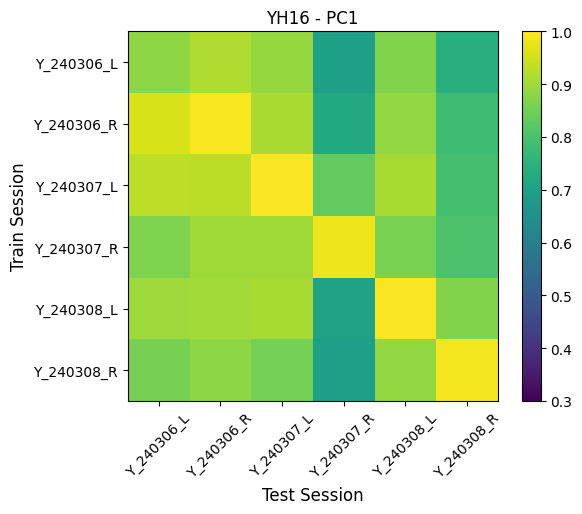

In [275]:
# HeatMap - YH16
PC = 1

Overall_PC_Performances = []

for train_sess in range(len(YH16_PERFORMANCES)):
    train_PC_perf = []
    for test_sess in range(len(YH16_PERFORMANCES)): 
        # Session # Performances
        Session_Performances_PC = YH16_PERFORMANCES[train_sess][test_sess][PC-1]
        train_PC_perf.append(Session_Performances_PC)
        
    Overall_PC_Performances.append(train_PC_perf)
    
print(Overall_PC_Performances) 

# HeatMap
Session_labels = ['Y_240306_L', 'Y_240306_R', 'Y_240307_L', 'Y_240307_R', 'Y_240308_L', 'Y_240308_R']
plt.imshow(Overall_PC_Performances, vmin = 0.3, vmax = 1)
plt.title(f'YH16 - PC{PC}')
plt.colorbar()
plt.xticks(np.arange(len(Session_labels)), Session_labels, rotation = 45)
plt.ylabel('Train Session', fontsize = 12)
plt.xlabel('Test Session', fontsize = 12)
plt.yticks(np.arange(len(Session_labels)), Session_labels)
plt.show()


[[0.9895035844978118, 0.8090738386699955, 0.8022790863291966, 0.0936607859875731, 0.2898891647988425, 0.271086961536415, 0.29257834343405253, 0.7849241528270638], [0.8221934868010489, 0.9909001330362853, 0.7644876718968908, 0.08683321286797563, 0.28388206636894375, 0.26963726176409986, 0.30130983824385105, 0.764852625220212], [0.14967351854509525, 0.18928617538607717, 0.9911305793157882, 0.10882454634897953, 0.31565371664655584, 0.32111040262606705, 0.35775346598106195, 0.8092924127429106], [0.1027040028938272, 0.15304105156815206, 0.5963301378150982, 0.986349572974222, 0.32383745287640286, 0.3228451653328832, 0.24021441739258786, 0.6926755898988152], [0.12229204171588148, 0.1631071750562486, 0.6683527892585024, 0.338131848787666, 0.9860491010164765, 0.6327621726186898, 0.2574035005967792, 0.6743841205881642], [0.15894420953442734, 0.18148902485215856, 0.6959527176042029, 0.3268760336688479, 0.724999436422719, 0.9818062011171427, 0.29217859714744887, 0.7744975520651983], [0.18901997411

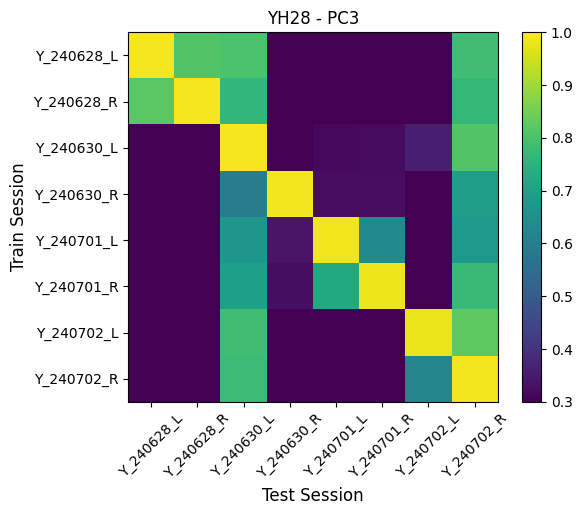

In [278]:
# HeatMap - YH28
PC = 3

Overall_PC_Performances = []

for train_sess in range(len(YH28_PERFORMANCES)):
    train_PC_perf = []
    for test_sess in range(len(YH28_PERFORMANCES)): 
        # Session # Performances
        Session_Performances_PC = YH28_PERFORMANCES[train_sess][test_sess][PC-1]
        train_PC_perf.append(Session_Performances_PC)
        
    Overall_PC_Performances.append(train_PC_perf)
    
print(Overall_PC_Performances) 

# HeatMap
Session_labels = ['Y_240628_L', 'Y_240628_R', 'Y_240630_L', 'Y_240630_R', 'Y_240701_L', 'Y_240701_R', 'Y_240702_L', 'Y_240702_R']
plt.imshow(Overall_PC_Performances, vmin = 0.3, vmax = 1)
plt.title(f'YH28 - PC{PC}')
plt.colorbar()
plt.xticks(np.arange(len(Session_labels)), Session_labels, rotation = 45)
plt.ylabel('Train Session', fontsize = 12)
plt.xlabel('Test Session', fontsize = 12)
plt.yticks(np.arange(len(Session_labels)), Session_labels)
plt.show()

[[0.9888939409259184, 0.8661321468009541, 0.6770132877530226, 0.2350242430630063, 0.13250396968993816, 0.7210959125203933, 0.4766906690338526, 0.28814882213594284, 0.2751567050920989, 0.37918735277632376], [0.7793393144602286, 0.9840124240454424, 0.6350553237148772, 0.24739748640705272, 0.13223938402756097, 0.7218939507509032, 0.4719984022144078, 0.300199130235588, 0.27888018947037074, 0.39578447334638944], [0.7210999467592836, 0.8265694210150487, 0.9836739218574142, 0.7162049738893408, 0.14808027260315448, 0.7257145643561197, 0.4808296099704048, 0.29081646090854396, 0.37165875889424893, 0.40275461390430733], [0.7037985391363533, 0.8088488113392877, 0.7577174591889226, 0.9827031159014417, 0.1438892186140357, 0.7138457448347831, 0.48171921870095136, 0.28595741068490355, 0.39444602576803245, 0.3877980337045257], [0.633485128992691, 0.7910915578663563, 0.6469747402943733, 0.2421517424925148, 0.9771371749173973, 0.7050632243457569, 0.5928180468461318, 0.311555481869773, 0.31747241993780106

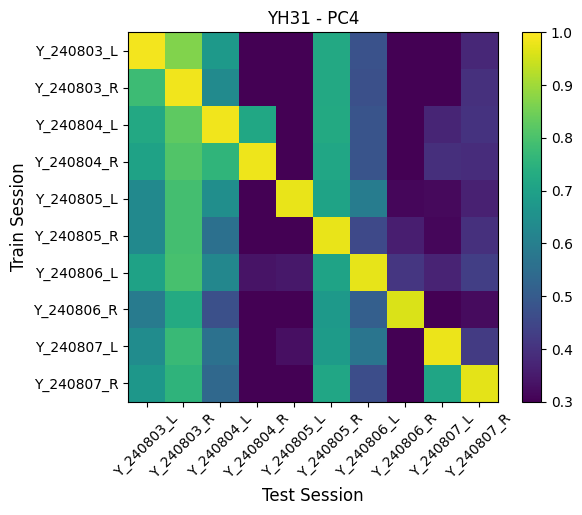

In [282]:
# HeatMap - YH31
PC = 4

Overall_PC_Performances = []

for train_sess in range(len(YH31_PERFORMANCES)):
    train_PC_perf = []
    for test_sess in range(len(YH31_PERFORMANCES)): 
        # Session # Performances
        Session_Performances_PC = YH31_PERFORMANCES[train_sess][test_sess][PC-1]
        train_PC_perf.append(Session_Performances_PC)
        
    Overall_PC_Performances.append(train_PC_perf)
    
print(Overall_PC_Performances) 

# HeatMap
Session_labels = ['Y_240803_L', 'Y_240803_R', 'Y_240804_L', 'Y_240804_R', 'Y_240805_L', 'Y_240805_R', 'Y_240806_L', 'Y_240806_R', 'Y_240807_L', 'Y_240807_R']
plt.imshow(Overall_PC_Performances, vmin = 0.3, vmax = 1)
plt.title(f'YH31 - PC{PC}')
plt.colorbar()
plt.xticks(np.arange(len(Session_labels)), Session_labels, rotation = 45)
plt.ylabel('Train Session', fontsize = 12)
plt.xlabel('Test Session', fontsize = 12)
plt.yticks(np.arange(len(Session_labels)), Session_labels)
plt.show()